In [1]:
# Import all required libraries for ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the clean dataset we saved in Week 1
df = pd.read_csv('../data/churn_clean.csv')

# Show basic info
print("✅ Dataset loaded successfully!")
print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")
print("\nFirst 5 rows:")
df.head()

✅ Dataset loaded successfully!
Total Rows    : 7043
Total Columns : 27

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_num,tenure_group,avg_monthly_spend,has_premium_services,is_high_value,num_services
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,No,0,New,14.925000,1,0,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.50,No,0,Mature,53.985714,1,1,3
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,Yes,1,New,36.050000,1,0,3
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,No,0,Mature,40.016304,1,0,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,Yes,1,New,50.550000,0,0,1


In [3]:
# Prepare data for ML model
print("=" * 50)
print("DATA PREPARATION")
print("=" * 50)

# Step 1: Drop columns we don't need for ML
df = df.drop(['customerID', 'Churn_num'], axis=1)

# Step 2: Convert target column Churn to numbers
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Step 3: Convert all text columns to numbers using LabelEncoder
le = LabelEncoder()
text_columns = df.select_dtypes(include=['object']).columns

print("Text columns being converted:")
for col in text_columns:
    df[col] = le.fit_transform(df[col])
    print(f"  → {col} converted to numbers")

print(f"\n✅ Data preparation complete!")
print(f"Total columns after preparation: {df.shape[1]}")

DATA PREPARATION
Text columns being converted:
  → gender converted to numbers
  → Partner converted to numbers
  → Dependents converted to numbers
  → PhoneService converted to numbers
  → MultipleLines converted to numbers
  → InternetService converted to numbers
  → OnlineSecurity converted to numbers
  → OnlineBackup converted to numbers
  → DeviceProtection converted to numbers
  → TechSupport converted to numbers
  → StreamingTV converted to numbers
  → StreamingMovies converted to numbers
  → Contract converted to numbers
  → PaperlessBilling converted to numbers
  → PaymentMethod converted to numbers
  → tenure_group converted to numbers

✅ Data preparation complete!
Total columns after preparation: 25


In [4]:
# Split data into training and testing sets
print("=" * 50)
print("TRAIN TEST SPLIT")
print("=" * 50)

# Step 1: Separate features (X) and target (y)
X = df.drop('Churn', axis=1)  # All columns except Churn
y = df['Churn']                # Only Churn column

print(f"Total Features  : {X.shape[1]}")
print(f"Total Samples   : {X.shape[0]}")

# Step 2: Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Step 3: Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\n✅ Data split and scaling complete!")
print(f"Training set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")

TRAIN TEST SPLIT
Total Features  : 24
Total Samples   : 7043

✅ Data split and scaling complete!
Training set : (5634, 24)
Testing set  : (1409, 24)


In [5]:
# Train XGBoost Model
print("=" * 50)
print("TRAINING XGBOOST MODEL")
print("=" * 50)

# Step 1: Create XGBoost model
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Step 2: Train the model
print("Training model... please wait ⏳")
model.fit(X_train, y_train)

# Step 3: Make predictions
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("✅ Model trained successfully!")

TRAINING XGBOOST MODEL
Training model... please wait ⏳
✅ Model trained successfully!


MODEL EVALUATION
✅ Accuracy  : 74.59%
🎯 Precision : 51.38%
🔁 Recall    : 79.41%
⚖️ F1 Score  : 62.39%


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stayed       0.91      0.73      0.81      1035
     Churned       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

CONFUSION MATRIX


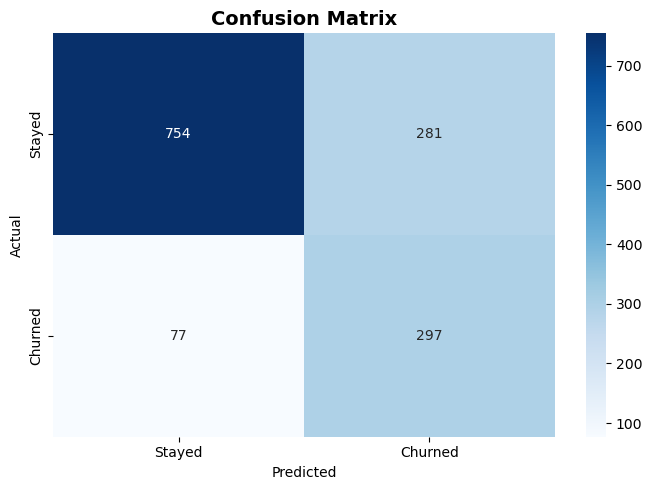


✅ Model evaluation complete!


In [6]:
# Evaluate model performance
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

# Step 1: Calculate metrics
accuracy  = accuracy_score(y_test, y_pred)  * 100
precision = precision_score(y_test, y_pred) * 100
recall    = recall_score(y_test, y_pred)    * 100
f1        = f1_score(y_test, y_pred)        * 100

print(f"✅ Accuracy  : {accuracy:.2f}%")
print(f"🎯 Precision : {precision:.2f}%")
print(f"🔁 Recall    : {recall:.2f}%")
print(f"⚖️ F1 Score  : {f1:.2f}%")

# Step 2: Classification Report
print("\n")
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['Stayed', 'Churned']))

# Step 3: Confusion Matrix
print("=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\n✅ Model evaluation complete!")

SHAP EXPLAINABILITY
📊 Feature Importance Chart:


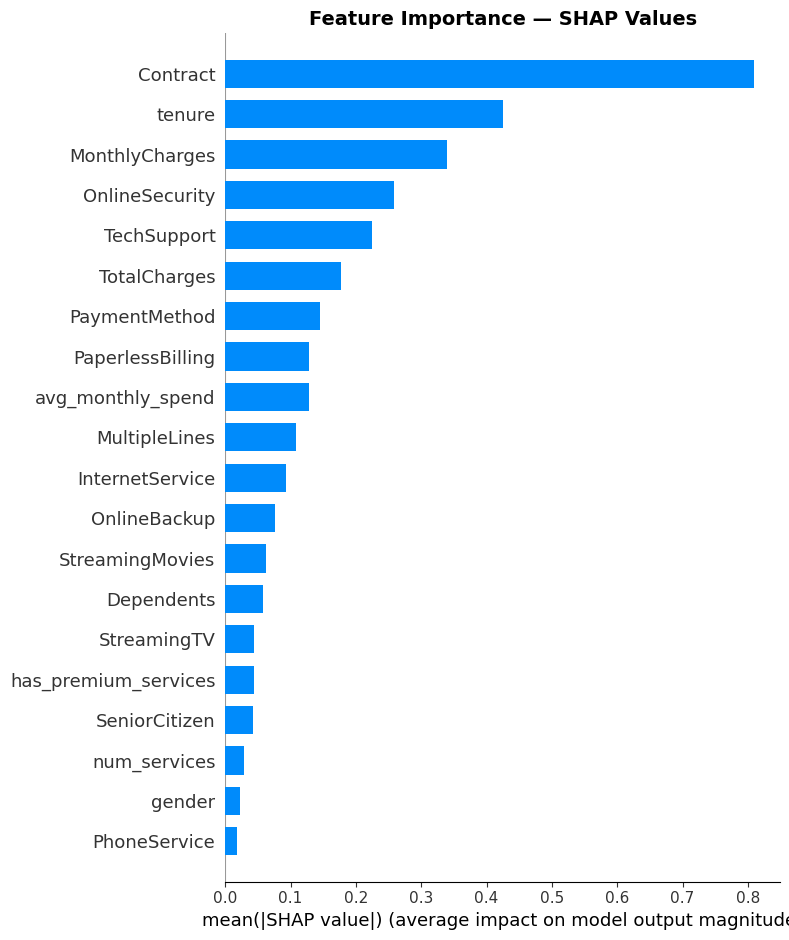

📊 SHAP Dot Plot:


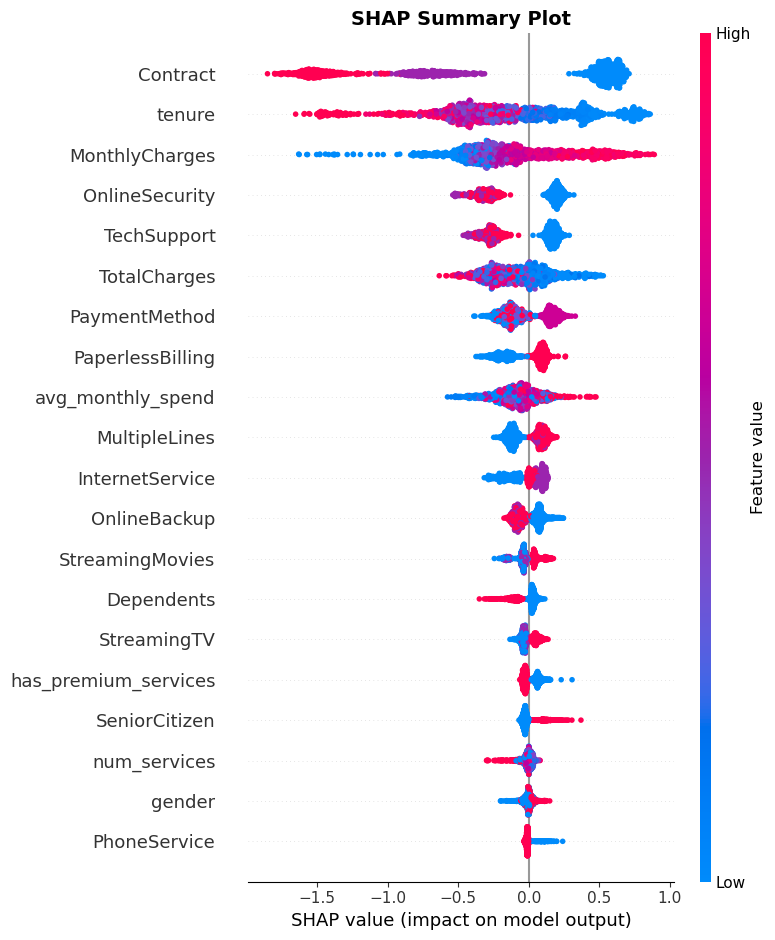


✅ SHAP analysis complete!


In [7]:
# SHAP Explainability — Why did model predict churn?
print("=" * 50)
print("SHAP EXPLAINABILITY")
print("=" * 50)

# Step 1: Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Step 2: Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Step 3: Feature Importance Plot
print("📊 Feature Importance Chart:")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.title("Feature Importance — SHAP Values",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Step 4: SHAP Dot Plot
print("📊 SHAP Dot Plot:")
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title("SHAP Summary Plot",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ SHAP analysis complete!")

In [9]:
# Save model and scaler for later use in Streamlit app
print("=" * 50)
print("SAVING MODEL")
print("=" * 50)

import joblib
import os

# Create models folder if not exists
os.makedirs('../models', exist_ok=True)

# Save XGBoost model
joblib.dump(model, '../models/xgboost_churn_model.pkl')
print("✅ XGBoost model saved!")

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')
print("✅ Scaler saved!")

# Save feature names
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../models/feature_names.pkl')
print("✅ Feature names saved!")

print("\n📁 All files saved in models/ folder:")
for file in os.listdir('../models'):
    print(f"  → {file}")

SAVING MODEL
✅ XGBoost model saved!
✅ Scaler saved!
✅ Feature names saved!

📁 All files saved in models/ folder:
  → feature_names.pkl
  → scaler.pkl
  → xgboost_churn_model.pkl
